<a href="https://colab.research.google.com/github/SNEHA-81/sneha.com/blob/main/Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

Employee attrition, the rate at which employees voluntarily leave an organization without being replaced, is a critical factor that impacts business operations, productivity, and costs. High attrition rates can lead to increased turnover costs, disruptions in workflows, and loss of valuable talent. To effectively manage and reduce attrition, it is essential for organizations to understand the underlying factors driving employees to leave.

This project aims to help a company analyze and understand employee attrition patterns, enabling better retention strategies and minimizing turnover. Through exploratory data analysis (EDA), we will explore the relationship between various factors and employee attrition, identifying the key variables that contribute to higher attrition rates. The ultimate goal is to build a predictive model that calculates the attrition rate, providing valuable insights into which factors are most likely to influence employees to leave, allowing organizations to address these issues proactively.

By understanding and addressing the root causes of attrition, organizations can improve employee retention, enhance morale, and ultimately reduce the financial and operational impacts associated with high turnover rates.

In [ ]:
# libraries for data gathering and visualization
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import iplot

# libraries for preprocessing and modeling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler,LabelEncoder,OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score,accuracy_score,confusion_matrix,precision_score,recall_score,roc_auc_score,roc_curve,auc,classification_report
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier ,RandomForestClassifier
import xgboost as xgb
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.pipeline import Pipeline

# for removing warnings
import warnings
warnings.filterwarnings("ignore")

!pip install prettytable

In [ ]:

# Loading the data from Excel
file_path = 'HR MIS.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Displaying the list of all columns
columns = df.columns
print(columns)


Index(['Emp ID', 'Date Of Joining', 'Date Of Birth', 'Date Of Exit',
       'Employment Status', 'Employee Type', 'Company_Name',
       'Parent Department Name', 'Current Department', 'Marital Status',
       'Gender', 'Separation Reason Category - Employee',
       'Separation Reason-Admin', 'Separation Category-Admin ',
       'Current Location Type', 'Current Location Area', 'Current Office Area',
       'Office State', 'Office City', 'Tenure', 'Tenure at Exit',
       'Tenure Classification', 'Age', 'Attrition Reason',
       'Expected Retirement Date', 'Years Until Retirement',
       'Engagement Score', 'Engagement Level', 'Last Promotion Date',
       'Time Since Last Promotion (M)', 'Promotion Impact',
       'Promotion Timeliness', 'Promotion Eligibility', 'Performance',
       'Potential', '9Box Score'],
      dtype='object')


The dataset comprises various attributes related to employee information, tenure, performance, and attrition details. Key columns include identifiers like 'Emp ID', demographic information such as 'Date Of Birth', 'Marital Status', and 'Gender', and employment-related data like 'Date Of Joining', 'Date Of Exit', and 'Employment Status'.

The dataset also provides detailed attrition insights through columns like 'Separation Reason Category - Employee', 'Attrition Reason', and 'Tenure at Exit'. Additionally, it includes engagement and performance metrics, such as 'Engagement Score', 'Promotion Eligibility', and '9Box Score'. These features offer a comprehensive view of employee lifecycle, performance, and factors influencing attrition.

In [ ]:
df

,Emp ID,Date Of Joining,Date Of Birth,Date Of Exit,Employment Status,Employee Type,Company_Name,Parent Department Name,Current Department,Marital Status,...,Engagement Score,Engagement Level,Last Promotion Date,Time Since Last Promotion (M),Promotion Impact,Promotion Timeliness,Promotion Eligibility,Performance,Potential,9Box Score
0,15,2019-12-02,1988-06-15,NaT,Active,Permanent,BluSmart Mobility Private Limited,Operations,Fleet Operations,Married,...,54,Low,2020-12-02,45.0,Promoted and Retained,0.20,Eligible,High,Low,3
1,16,2020-02-17,1983-07-14,NaT,Active,Permanent,BluSmart Mobility Private Limited,Operations,Airport Operations,NaN,...,78,Medium,2023-02-17,19.0,Promoted and Retained,0.75,Not Eligible,Medium,High,8
2,34,2023-03-18,1989-01-01,NaT,Active,Permanent,BluSmart Mobility Private Limited,Operations,Hub Operations,Married,...,60,Medium,NaT,NaN,Not Promoted,NaN,Not Eligible,Medium,Low,2
3,39,2023-06-05,1993-07-07,NaT,Active,Permanent,BluSmart Mobility Private Limited,Operations,Business Development,Single,...,63,Medium,NaT,NaN,Not Promoted,NaN,Not Eligible,Medium,High,8
4,48,2023-04-01,1998-07-23,NaT,Active,Permanent,BluSmart Mobility Private Limited,Operations,Hub Operations,Single,...,73,Medium,NaT,NaN,Not Promoted,NaN,Not Eligible,High,Low,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1408,1379,2023-02-20,1989-02-08,2023-11-24,Inactive,Permanent,BluSmart Mobility Private Limited,Operations,CXO's Office,NaN,...,50,Low,NaT,NaN,Not Promoted,NaN,Not Eligible,High,Low,3
1409,1380,2023-08-16,1994-02-02,2023-12-14,Inactive,Permanent,BluSmart Mobility Private Limited,Operations,Airport Operations,NaN,...,55,Low,NaT,NaN,Not Promoted,NaN,Not Eligible,Low,High,7
1410,1381,2019-11-04,1994-12-03,2023-05-27,Inactive,Permanent,BluSmart Mobility Private Limited,Technology,Software Development,NaN,...,76,Medium,2020-11-04,46.0,Promoted and Left,0.20,Eligible,Medium,High,8
1411,1382,2022-06-16,1995-07-28,2023-07-24,Inactive,Permanent,BluSmart Mobility Private Limited,NaN,Customer Experience,NaN,...,62,Medium,NaT,NaN,Not Promoted,NaN,Not Eligible,High,Medium,6


In [ ]:
df.shape

(1413, 36)

In [ ]:
df.isnull().sum()

,0
Emp ID,0
Date Of Joining,0
Date Of Birth,0
Date Of Exit,1023
Employment Status,0
Employee Type,0
Company_Name,0
Parent Department Name,434
Current Department,0
Marital Status,591


In [ ]:
# Count the number of active and inactive employees
status_counts = df['Employment Status'].value_counts()
print(status_counts)

Employment Status
Active      1028
Inactive     385
Name: count, dtype: int64


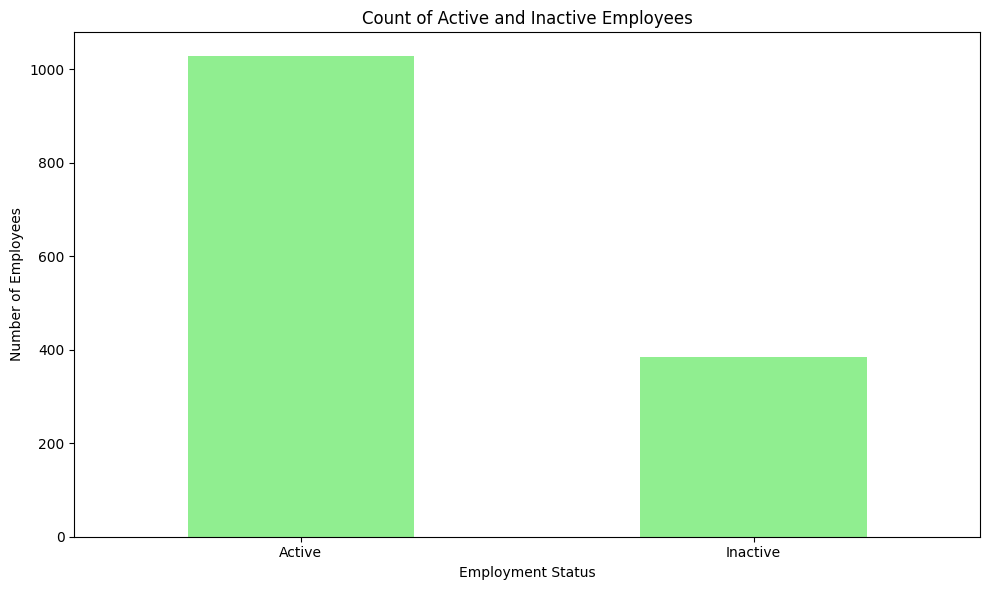

In [ ]:
# Plotting the bar chart
plt.figure(figsize=(10, 6))
status_counts.plot(kind='bar', color='lightgreen')
plt.title('Count of Active and Inactive Employees')
plt.xlabel('Employment Status')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

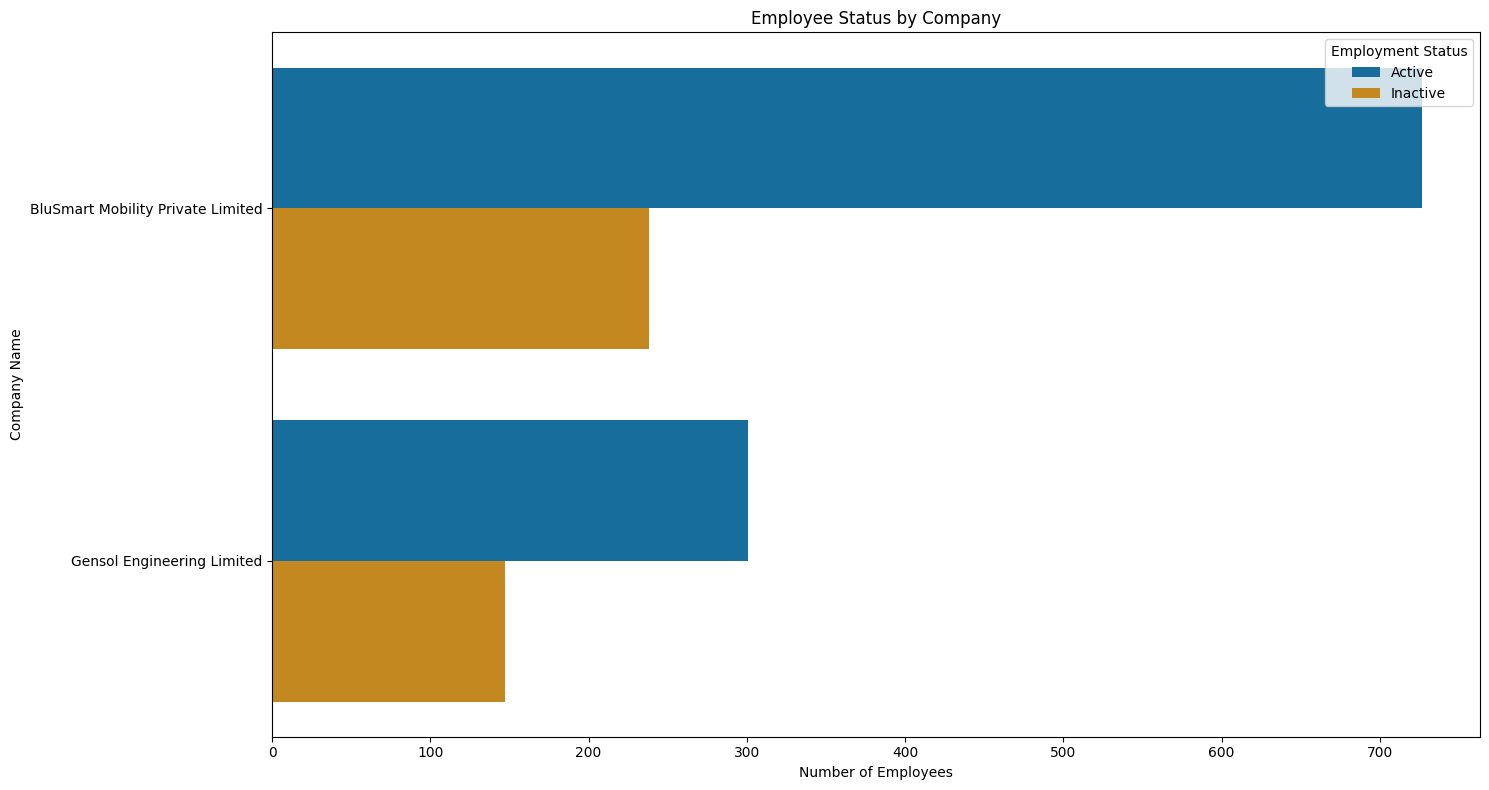

In [ ]:
# Create a new DataFrame for employment status by company
company_data = df[['Company_Name', 'Employment Status']].copy()

# Plotting the horizontal countplot for Employment Status by Company
plt.subplots(figsize=(15, 8))
sns.countplot(y='Company_Name', hue='Employment Status', data=company_data, palette='colorblind')
plt.title('Employee Status by Company')
plt.xlabel('Number of Employees')
plt.ylabel('Company Name')
plt.legend(title='Employment Status', loc='upper right', labels=['Active', 'Inactive'])
plt.tight_layout()
plt.show()

In [ ]:
# Filter out inactive employees and check if they have a valid exit date
inactive_employees = df[df['Employment Status'] == 'Inactive']
inactive_with_exit_date = inactive_employees['Date Of Exit'].notna().sum()
total_inactive = inactive_employees.shape[0]

print(f'Total number of inactive employees: {total_inactive}')
print(f'Number of inactive employees with a valid exit date: {inactive_with_exit_date}')


Total number of inactive employees: 385
Number of inactive employees with a valid exit date: 385


In [ ]:
# Percentage of inactive employees with a recorded exit date
inactive_exit_percentage = (inactive_with_exit_date / total_inactive) * 100 if total_inactive > 0 else 0
print(f"{inactive_exit_percentage:.2f}% of inactive employees have a recorded exit date.")


100.00% of inactive employees have a recorded exit date.


In [ ]:
# Filter for inactive employees
inactive_employees = df[df['Employment Status'] == 'Inactive']

# Count the number of employees for each attrition reason
attrition_reason_counts = inactive_employees['Attrition Reason'].value_counts()
print(attrition_reason_counts)

Attrition Reason
Personal Reasons                                        204
Reason Not Captured                                      69
Termination                                              45
Absconding                                               15
Backout                                                  12
Asked To Leave                                           10
For better growth and career opportunities                7
Transferred to a different group company.                 6
Dishonesty, evasion, or lack of integrity on the job      5
Performance Reason                                        5
Personal or family commitments                            2
Medical Reason                                            1
Role Redundant                                            1
Better Career Opportunity                                 1
For better pay package                                    1
Health Issues                                             1
Name: count, dtype: int

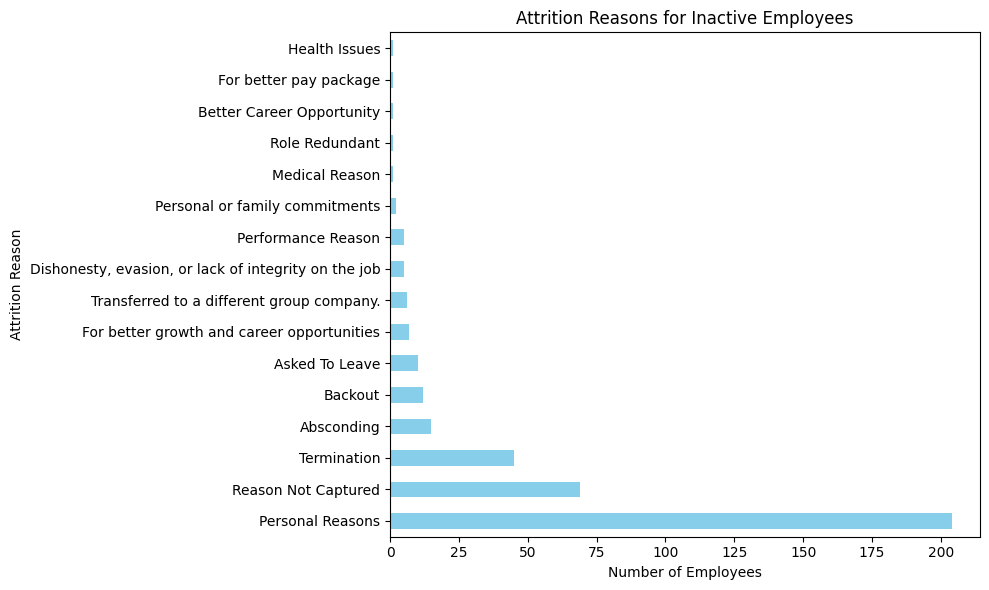

In [ ]:
# Plotting the horizontal bar chart
plt.figure(figsize=(10, 6))
attrition_reason_counts.plot(kind='barh', color='skyblue')
plt.title('Attrition Reasons for Inactive Employees')
plt.xlabel('Number of Employees')
plt.ylabel('Attrition Reason')
plt.tight_layout()
plt.show()

The analysis of attrition reasons reveals a diverse set of factors influencing employee departures within the organization. The most prevalent reason is "Personal Reasons," accounting for 204 exits, followed by "Reason Not Captured" with 69 instances. Other significant reasons include "Termination" (45), "Absconding" (15), and "Backout" (12). Additionally, some employees left for positive motivations, such as seeking "Better Growth and Career Opportunities" (7) or being "Transferred to a Different Group Company" (6). Notably, issues related to performance and integrity also contributed to attrition, highlighting potential areas for improvement in employee management and support.

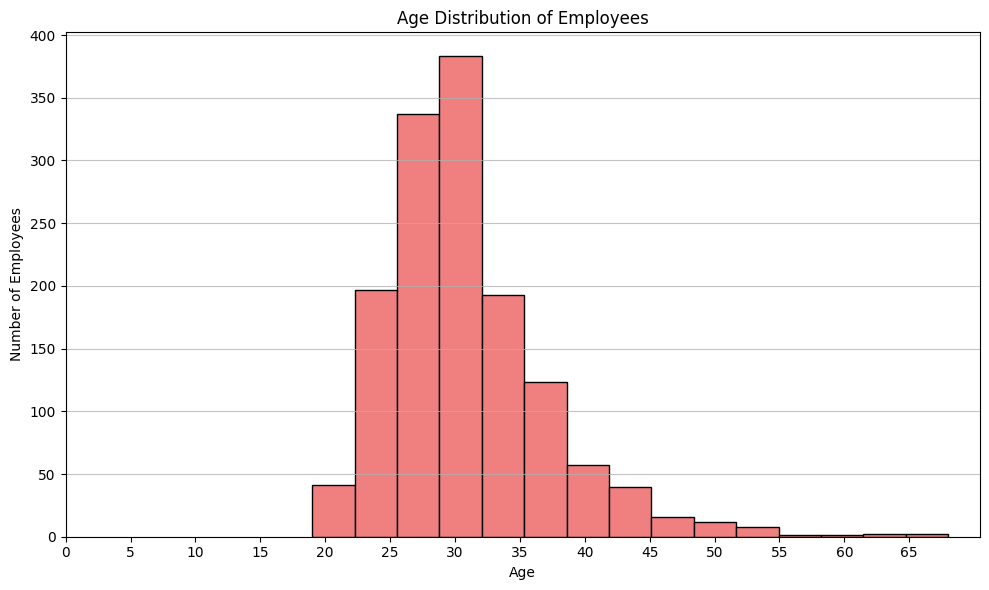

In [ ]:
# Calculate the age of employees
current_date = datetime.now()
df['Age'] = (current_date - pd.to_datetime(df['Date Of Birth'])).dt.days // 365

# Plotting the histogram of ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=15, color='lightcoral', edgecolor='black')
plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.xticks(range(0, df['Age'].max() + 1, 5))  # Set x-ticks every 5 years
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()  # Adjust layout to fit labels
plt.show()

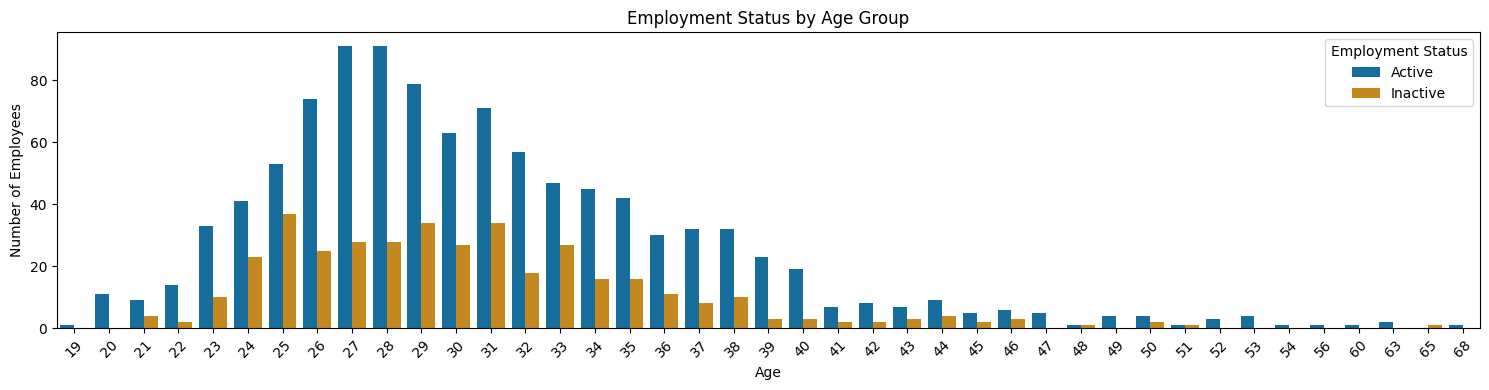

In [ ]:
# Create a new DataFrame for employment status analysis
employment_data = df[['Age', 'Employment Status']].copy()

# Plotting the countplot for Age vs. Employment Status
plt.subplots(figsize=(15, 4))
sns.countplot(x='Age', hue='Employment Status', data=employment_data, palette='colorblind')
plt.title('Employment Status by Age Group')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.legend(title='Employment Status', loc='upper right', labels=['Active', 'Inactive'])
plt.xticks(rotation=45)  # Rotate x-ticks for better readability
plt.tight_layout()
plt.show()

The proportion of employees who left was comparatively less among the senior level employees. Maybe these employees were at a higher authority and were less likely to leave that position.

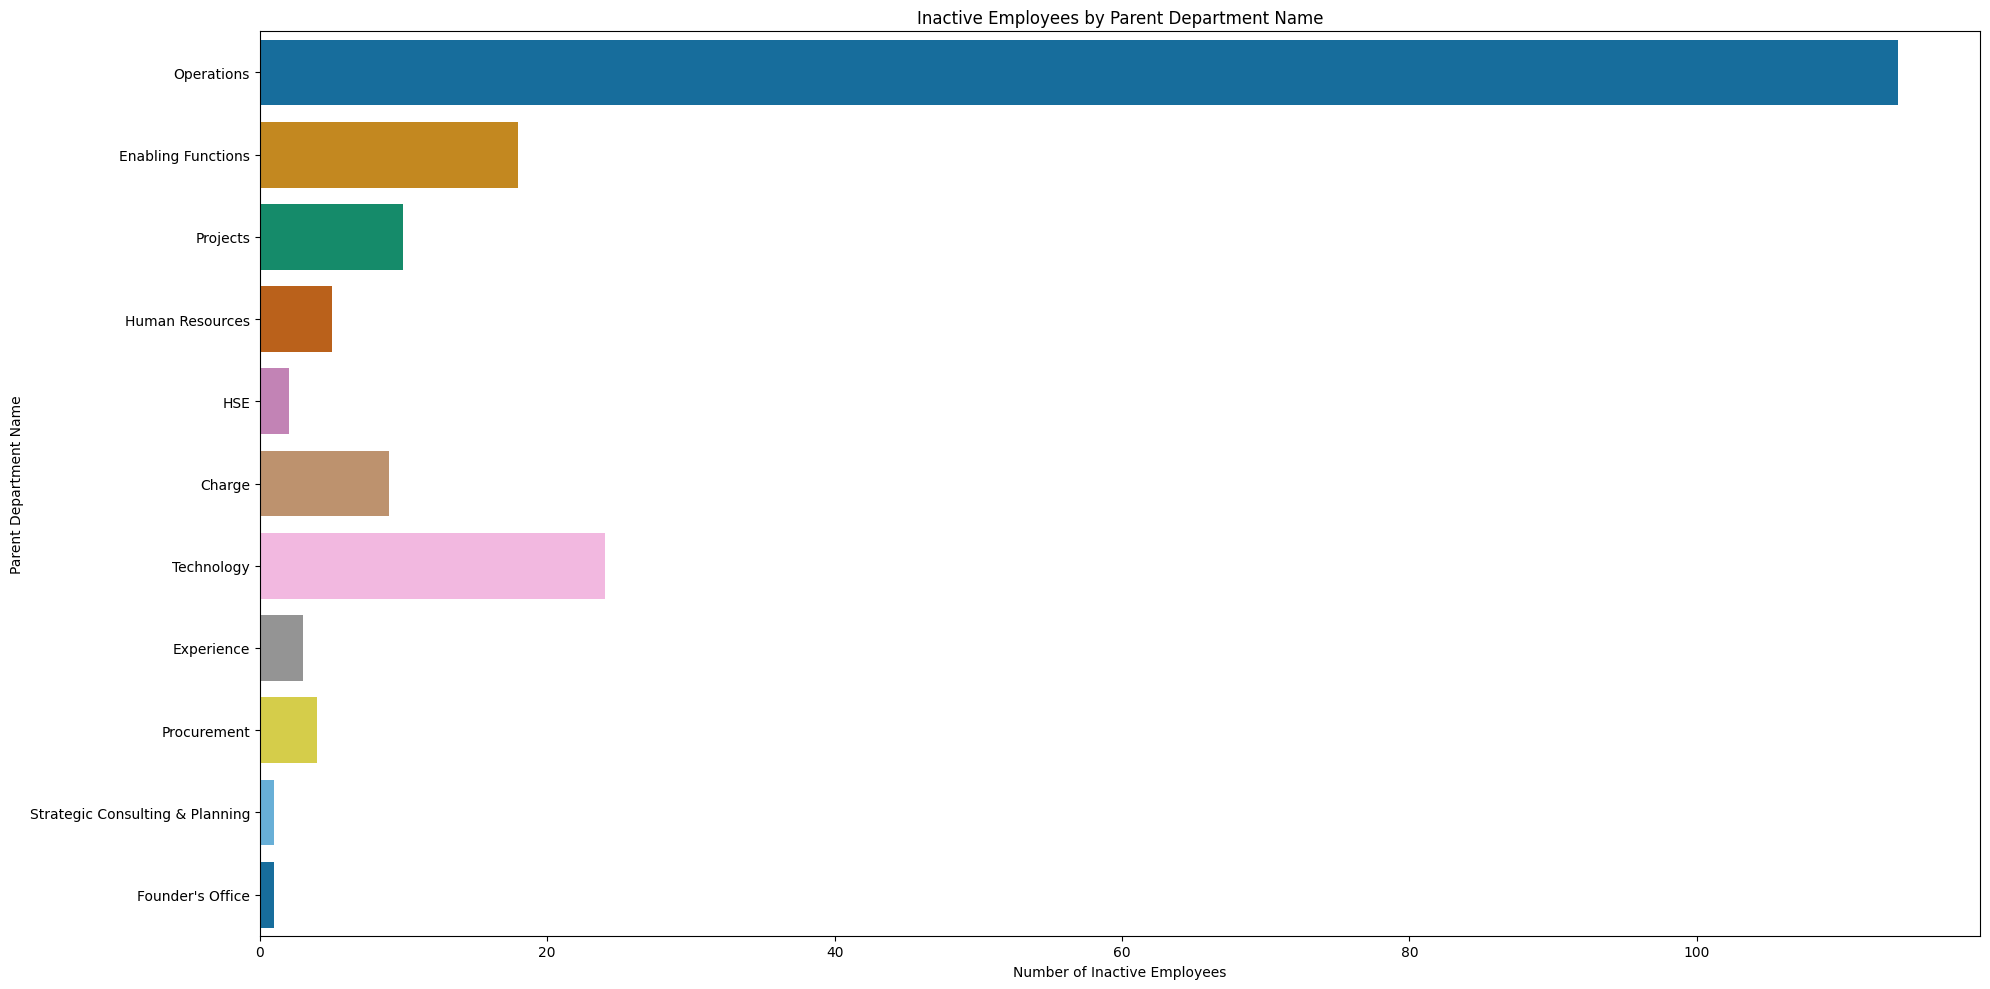

In [ ]:
# Create a new DataFrame for inactive employees by department   // field change for this(parental dept)

inactive_department_data = df[df['Employment Status'] == 'Inactive'][['Parent Department Name', 'Employment Status']]

# Plotting the countplot for Inactive Employees by Parent Department Name
plt.subplots(figsize=(20, 10))
sns.countplot(y='Parent Department Name', data=inactive_department_data, palette='colorblind')
plt.title('Inactive Employees by Parent Department Name')
plt.xlabel('Number of Inactive Employees')
plt.ylabel('Parent Department Name')
plt.tight_layout()
plt.show()

In [ ]:
# Count total employees by gender   //tabular  form of data
total_male = df[df['Gender'] == 'Male'].shape[0]
total_female = df[df['Gender'] == 'Female'].shape[0]

# Count inactive employees by gender
inactive_male = df[(df['Gender'] == 'Male') & (df['Employment Status'] == 'Inactive')].shape[0]
inactive_female = df[(df['Gender'] == 'Female') & (df['Employment Status'] == 'Inactive')].shape[0]

# Calculate attrition percentage
attrition_percentage_male = (inactive_male / total_male) * 100 if total_male > 0 else 0
attrition_percentage_female = (inactive_female / total_female) * 100 if total_female > 0 else 0

# Data for table
data = {
    'Gender': ['Male', 'Female'],
    'Total Employees': [total_male, total_female],
    'Inactive Employees': [inactive_male, inactive_female],
    'Attrition Percentage (%)': [attrition_percentage_male, attrition_percentage_female]
}

# Create DataFrame
attrition_df = pd.DataFrame(data)

# Display the DataFrame as a table
print(attrition_df)


NameError: name 'df' is not defined

The analysis of employee attrition reveals that there are a total of **1,197 male employees** and **216 female employees** in the organization. Among these, **326 male employees** (27.23%) and **59 female employees** (27.31%) have become inactive. The attrition rates for both genders are quite similar, indicating that male employees face a slightly lower turnover rate compared to female employees. This insight highlights the need for targeted retention strategies to address the factors contributing to employee departures across both male and female demographics.

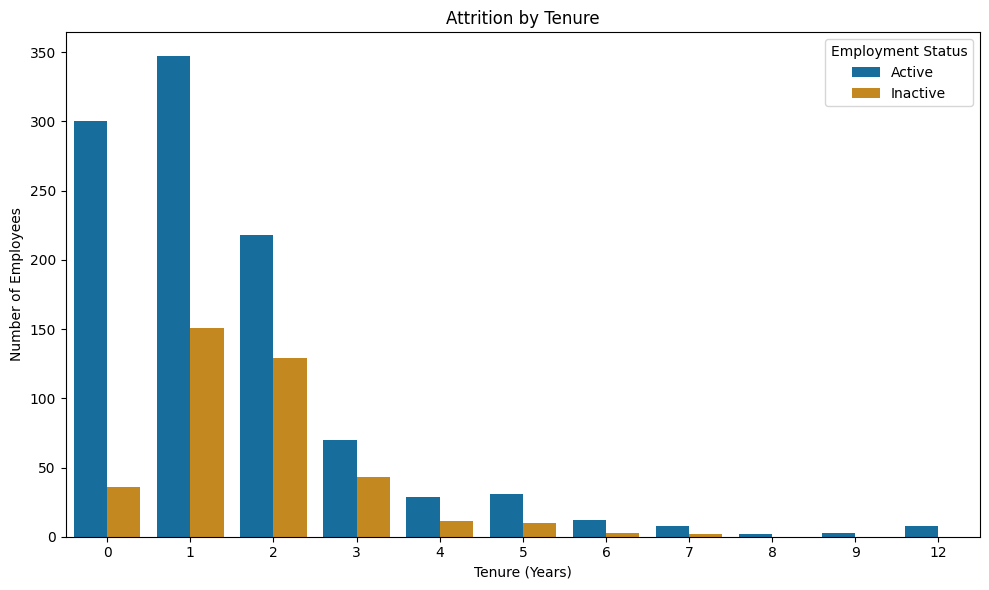

At tenure of 0 years, there are 36 attritions.
At tenure of 1 years, there are 151 attritions.
At tenure of 2 years, there are 129 attritions.
At tenure of 3 years, there are 43 attritions.
At tenure of 4 years, there are 11 attritions.
At tenure of 5 years, there are 10 attritions.
At tenure of 6 years, there are 3 attritions.
At tenure of 7 years, there are 2 attritions.


In [ ]:
tenure_data = df[['Tenure', 'Employment Status']].copy()

# Plotting the countplot for Attrition by Tenure
plt.subplots(figsize=(10, 6))
sns.countplot(x='Tenure', hue='Employment Status', data=tenure_data, palette='colorblind')
plt.title('Attrition by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Number of Employees')
plt.legend(title='Employment Status', loc='upper right', labels=['Active', 'Inactive'])
plt.xticks(rotation=0)  # Rotate x-ticks if necessary
plt.tight_layout()
plt.show()

attrition_counts = tenure_data[tenure_data['Employment Status'] == 'Inactive'].groupby('Tenure').size()

for tenure, count in attrition_counts.items():
    print(f'At tenure of {tenure} years, there are {count} attritions.')

# chunk analysis
# tenure calc as per date of exit and joining

The attrition analysis reveals that the highest number of employee departures occurs within the first year of tenure, with 151 attritions at 1 year. This is followed by 129 attritions at 2 years and 36 attritions at 0 years.

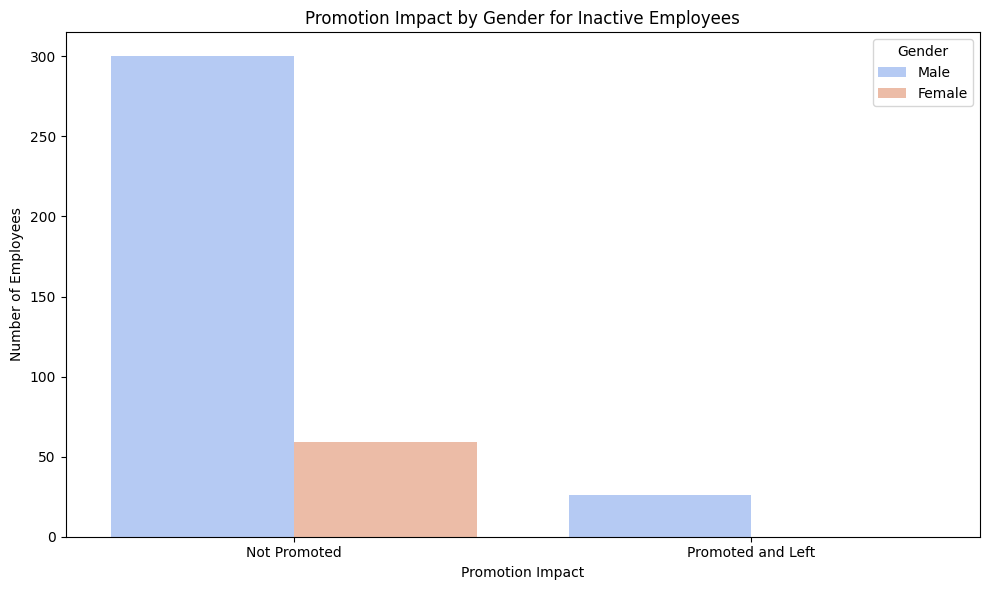

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Promotion Impact', hue='Gender', data=df[df['Employment Status'] == 'Inactive'], palette='coolwarm')
plt.title('Promotion Impact by Gender for Inactive Employees')
plt.xlabel('Promotion Impact')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()


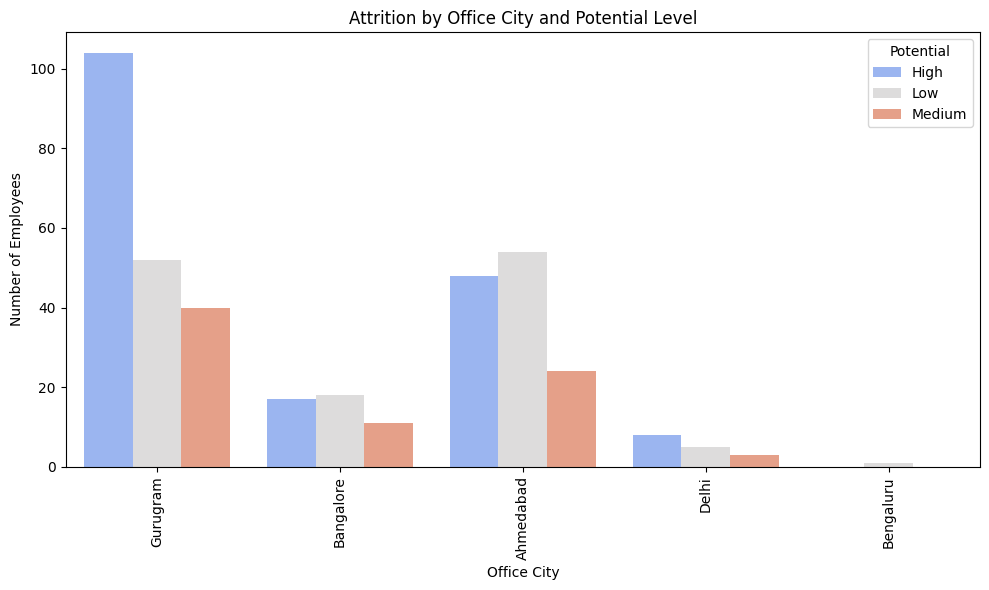

In [ ]:
# Analyze whether employees with high potential are more likely to leave in certain office locations.

plt.figure(figsize=(10, 6))
sns.countplot(x='Office City', hue='Potential', data=df[df['Employment Status'] == 'Inactive'], palette='coolwarm')
plt.title('Attrition by Office City and Potential Level')
plt.xlabel('Office City')
plt.ylabel('Number of Employees')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


At tenure classification "Long-term", there are 5 attritions.
At tenure classification "Mid-term", there are 21 attritions.
At tenure classification "New Joiner", there are 36 attritions.
At tenure classification "Short-term", there are 323 attritions.


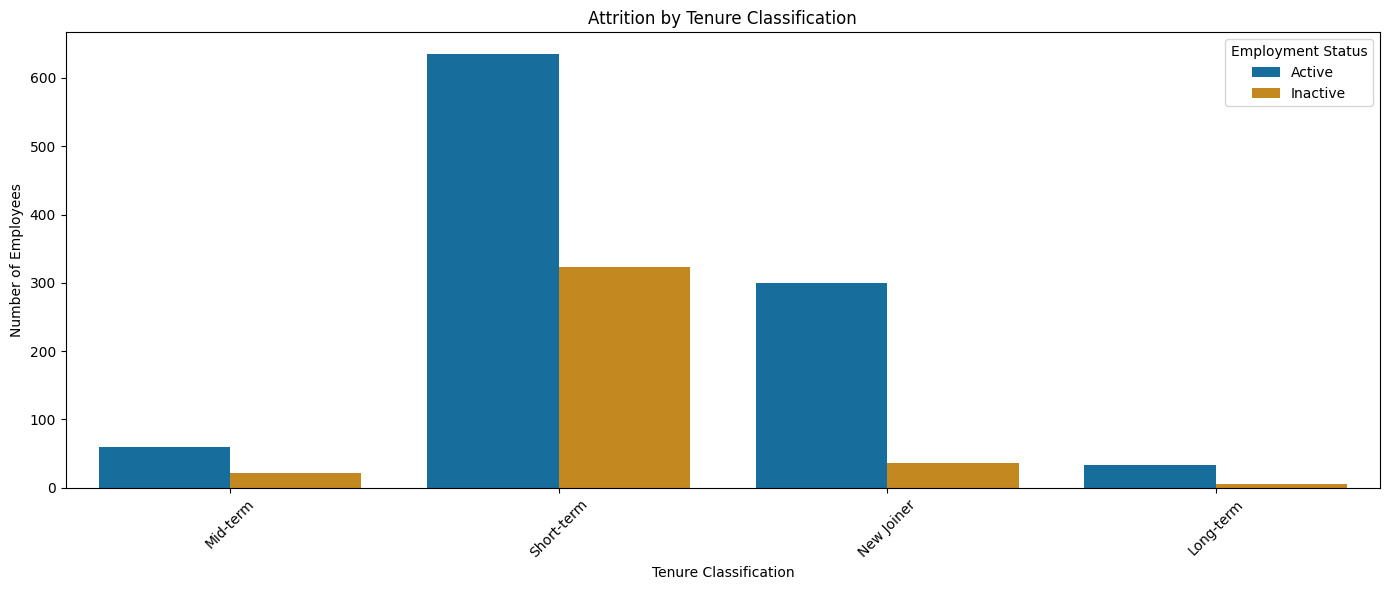

In [ ]:
tenure_classification_data = df[['Tenure Classification', 'Employment Status']].copy()

# Count attrition numbers for each tenure classification
attrition_classification_counts = tenure_classification_data[tenure_classification_data['Employment Status'] == 'Inactive'].groupby('Tenure Classification').size()

# Print attrition counts by tenure classification
for classification, count in attrition_classification_counts.items():
    print(f'At tenure classification "{classification}", there are {count} attritions.')

# Plotting the countplot for Attrition by Tenure Classification
plt.subplots(figsize=(14, 6))
sns.countplot(x='Tenure Classification', hue='Employment Status', data=tenure_classification_data, palette='colorblind')
plt.title('Attrition by Tenure Classification')
plt.xlabel('Tenure Classification')
plt.ylabel('Number of Employees')
plt.legend(title='Employment Status', loc='upper right', labels=['Active', 'Inactive'])
plt.xticks(rotation=45)  # Rotate x-ticks for better readability
plt.tight_layout()
plt.show()

The analysis of engagement scores between active and inactive employees reveals the following insights:

- **Median Scores:** Both groups exhibit similar median engagement scores, ranging from **65 to 70**, indicating a comparable level of engagement overall.
- **Variability:** Inactive employees demonstrate greater variability in their engagement scores, suggesting a wider range of experiences.
- **Outliers:** Both active and inactive employees feature high-scoring outliers, with scores typically falling between **50 and 90**.
- **Clustering:** Active employees' scores are more closely clustered around the median, reflecting a more consistent engagement level among this group.

These findings suggest that while the median engagement levels are similar, the differences in variability and clustering could provide valuable insights for improving retention strategies, especially targeting the factors influencing disengagement in the inactive group.

In [ ]:
eligible_for_promotion = df[df['Promotion Eligibility'] == 'Eligible']

# Count total eligible employees
total_eligible = eligible_for_promotion.shape[0]

# Count inactive employees (attritions) among those eligible
attritions_eligible = eligible_for_promotion[eligible_for_promotion['Employment Status'] == 'Inactive'].shape[0]

# Calculate attrition rate
attrition_rate_eligible = (attritions_eligible / total_eligible) * 100 if total_eligible > 0 else 0

# Print results
print(f'Total eligible employees for promotion: {total_eligible}')
print(f'Attritions among eligible employees: {attritions_eligible}')
print(f'Attrition rate among eligible employees for promotion: {attrition_rate_eligible:.2f}%')

Total eligible employees for promotion: 94
Attritions among eligible employees: 20
Attrition rate among eligible employees for promotion: 21.28%


Out of a total of 94 employees eligible for promotion, 20 have left the organization, resulting in an attrition rate of 21.28% among this group. This indicates that a significant portion of employees eligible for advancement is departing, suggesting a need for further investigation into the factors influencing their decisions to leave.



### Performance vs Attrition

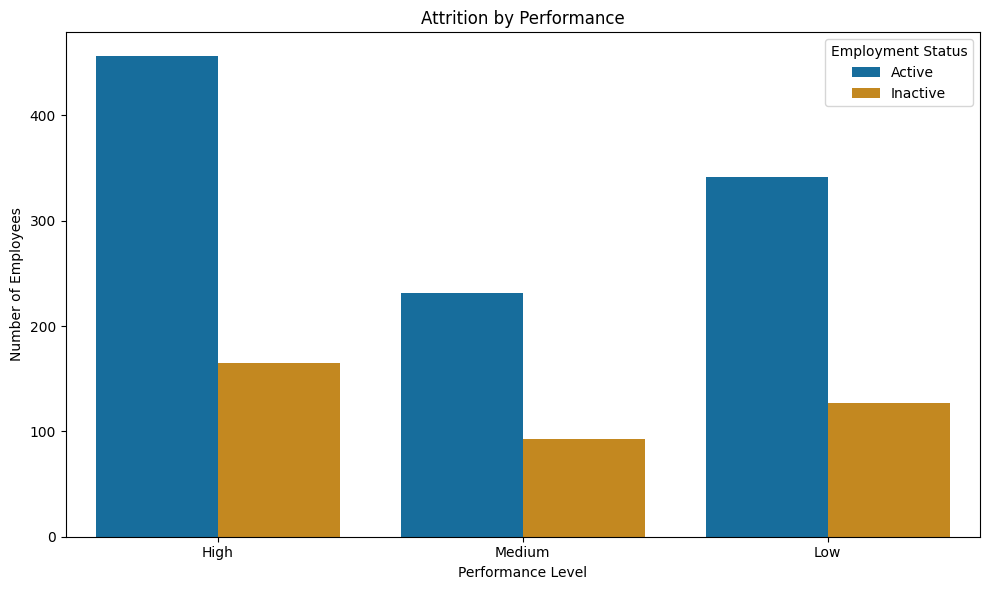

In [ ]:
performance_data = df[['Performance', 'Employment Status']].copy()  # chunk wise, kind of high performance from which dept

# Plotting the countplot for Performance by Employment Status
plt.subplots(figsize=(10, 6))
sns.countplot(x='Performance', hue='Employment Status', data=performance_data, palette='colorblind')
plt.title('Attrition by Performance')
plt.xlabel('Performance Level')
plt.ylabel('Number of Employees')
plt.legend(title='Employment Status', loc='upper right', labels=['Active', 'Inactive'])
plt.xticks(rotation=0)  # Rotate x-ticks if necessary
plt.tight_layout()
plt.show()

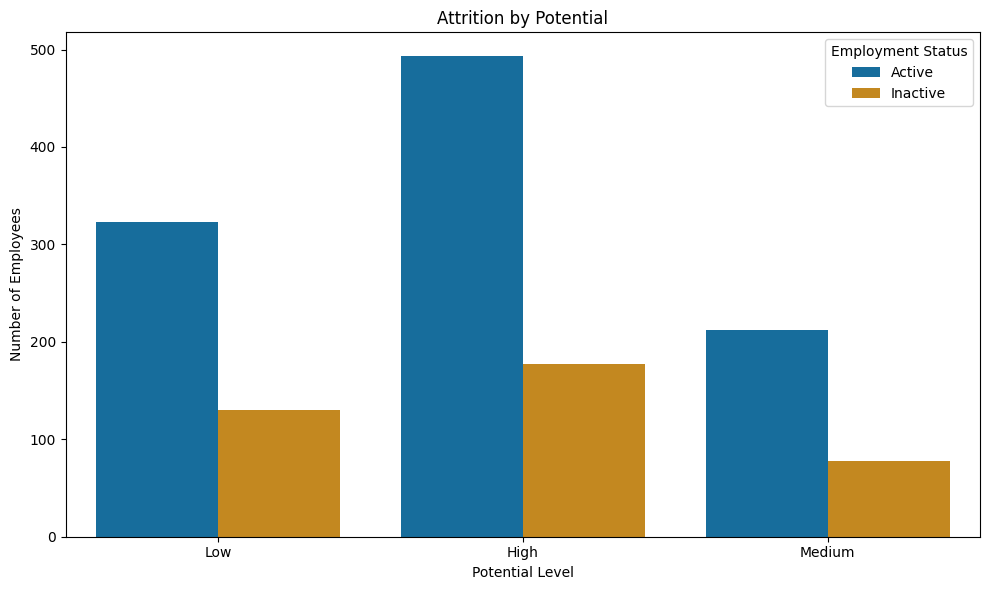

In [ ]:
potential_data = df[['Potential', 'Employment Status']].copy()

# Plotting the countplot for Potential by Employment Status
plt.subplots(figsize=(10, 6))
sns.countplot(x='Potential', hue='Employment Status', data=potential_data, palette='colorblind')
plt.title('Attrition by Potential')
plt.xlabel('Potential Level')
plt.ylabel('Number of Employees')
plt.legend(title='Employment Status', loc='upper right', labels=['Active', 'Inactive'])
plt.xticks(rotation=0)  # Rotate x-ticks if necessary
plt.tight_layout()
plt.show()

In [ ]:
# Calculate attrition rates based on Performance
performance_attrition_rates = performance_data.groupby('Performance')['Employment Status'].value_counts(normalize=True).unstack().fillna(0) * 100
print("\nAttrition Rates by Performance:")
print(performance_attrition_rates[['Inactive']])

# Calculate attrition rates based on Potential
potential_attrition_rates = potential_data.groupby('Potential')['Employment Status'].value_counts(normalize=True).unstack().fillna(0) * 100
print("\nAttrition Rates by Potential:")
print(potential_attrition_rates[['Inactive']])


Attrition Rates by Performance:
Employment Status   Inactive
Performance                 
High               26.570048
Low                27.136752
Medium             28.703704

Attrition Rates by Potential:
Employment Status   Inactive
Potential                   
High               26.417910
Low                28.697572
Medium             26.896552


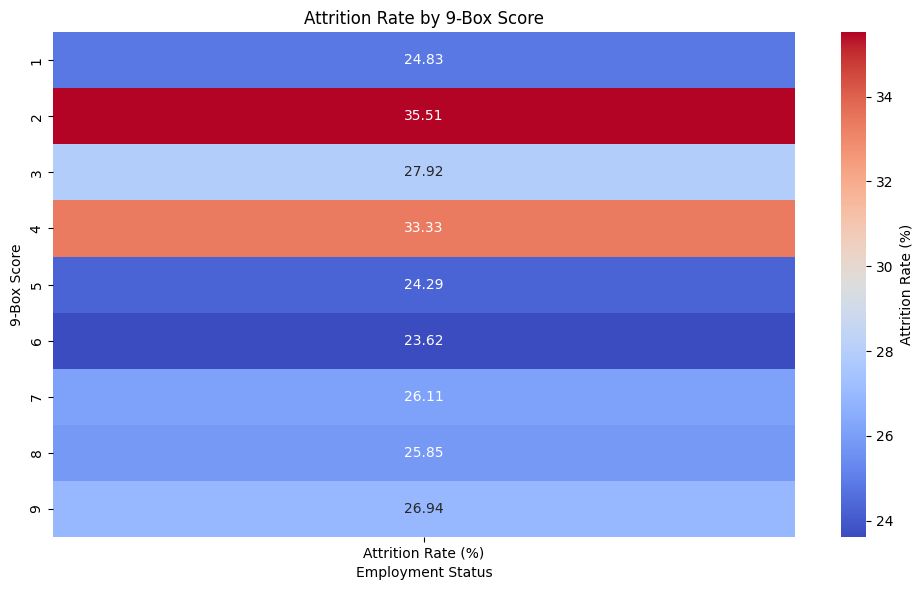

In [ ]:
# Create a new DataFrame for the 9-Box Score analysis
nine_box_data = df[['9Box Score', 'Employment Status']].copy()

# Create a pivot table to calculate attrition counts
nine_box_pivot = nine_box_data.pivot_table(index='9Box Score', columns='Employment Status', aggfunc='size', fill_value=0)

# Calculate attrition rate for each box
nine_box_pivot['Attrition Rate (%)'] = (nine_box_pivot['Inactive'] / nine_box_pivot.sum(axis=1)) * 100

# Plotting the heatmap for 9-Box Score attrition rates
plt.figure(figsize=(10, 6))
sns.heatmap(nine_box_pivot[['Attrition Rate (%)']], annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Attrition Rate (%)'})
plt.title('Attrition Rate by 9-Box Score')
plt.xlabel('Employment Status')
plt.ylabel('9-Box Score')
plt.tight_layout()
plt.show()


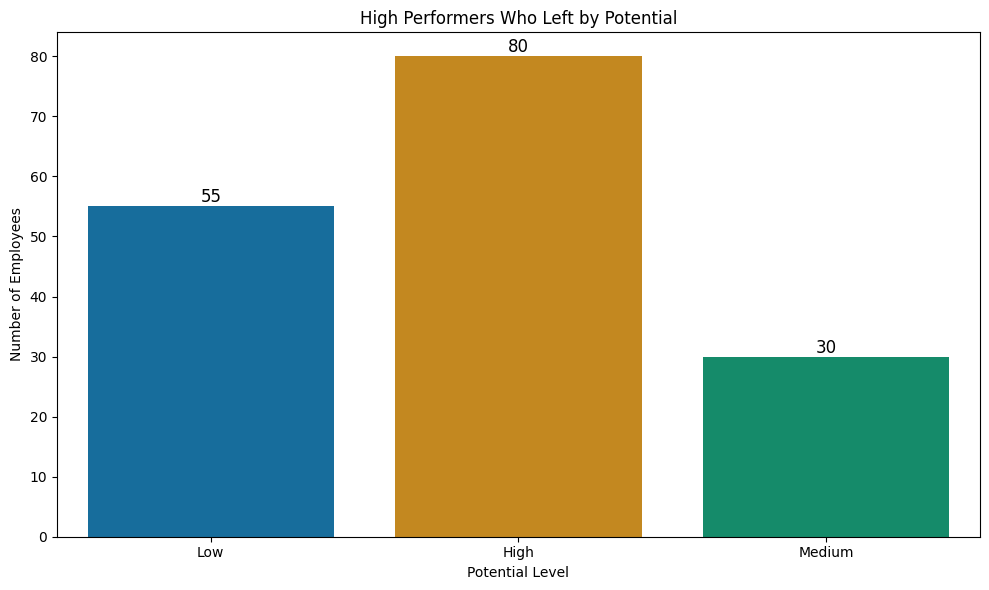

In [ ]:
# Subset of high performers who left the company
high_performers_left = df[(df['Performance'] == 'High') & (df['Employment Status'] == 'Inactive')]

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Potential', data=high_performers_left, palette='colorblind')

# Add counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

# Set titles and labels
plt.title('High Performers Who Left by Potential')
plt.xlabel('Potential Level')
plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()


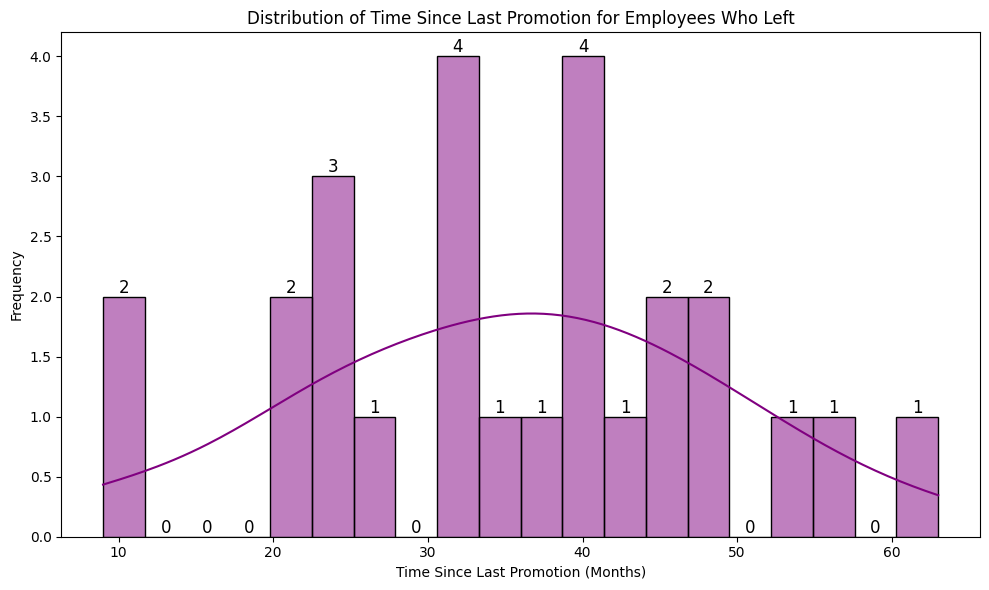

In [ ]:
# Subset of employees who left the company and analyze Time Since Last Promotion
left_employees = df[df['Employment Status'] == 'Inactive']

plt.figure(figsize=(10, 6))
ax = sns.histplot(left_employees['Time Since Last Promotion (M)'], bins=20, kde=True, color='purple')

# Add counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

# Set titles and labels
plt.title('Distribution of Time Since Last Promotion for Employees Who Left')
plt.xlabel('Time Since Last Promotion (Months)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


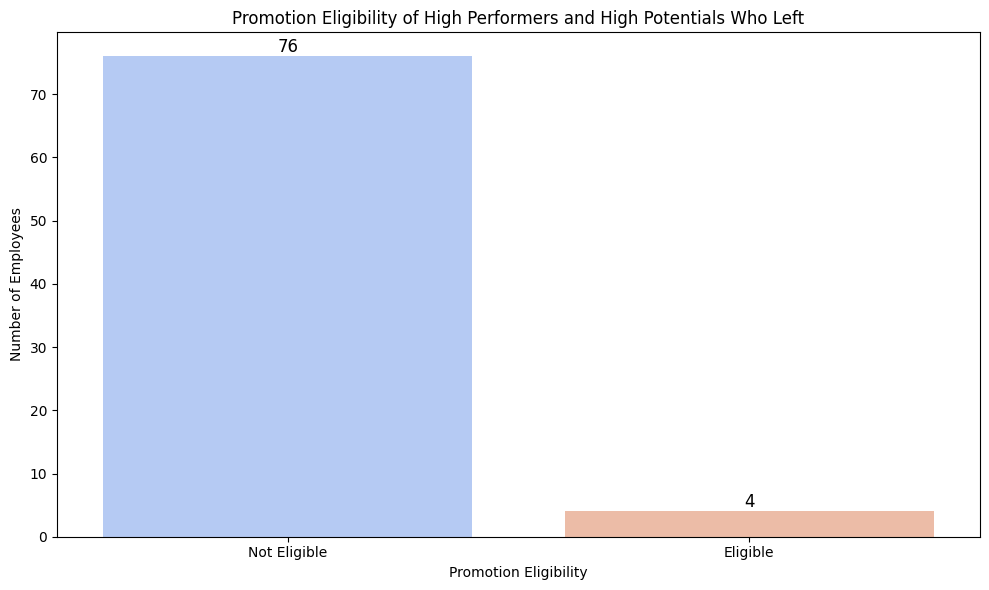

In [ ]:
# Subset of high performers and high potential employees who left
high_perf_potential_left = df[(df['Performance'] == 'High') &
                              (df['Potential'] == 'High') &
                              (df['Employment Status'] == 'Inactive')]

# Analyze promotion eligibility of this subset
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Promotion Eligibility', data=high_perf_potential_left, palette='coolwarm')

# Add counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

# Set titles and labels
plt.title('Promotion Eligibility of High Performers and High Potentials Who Left')
plt.xlabel('Promotion Eligibility')
plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()


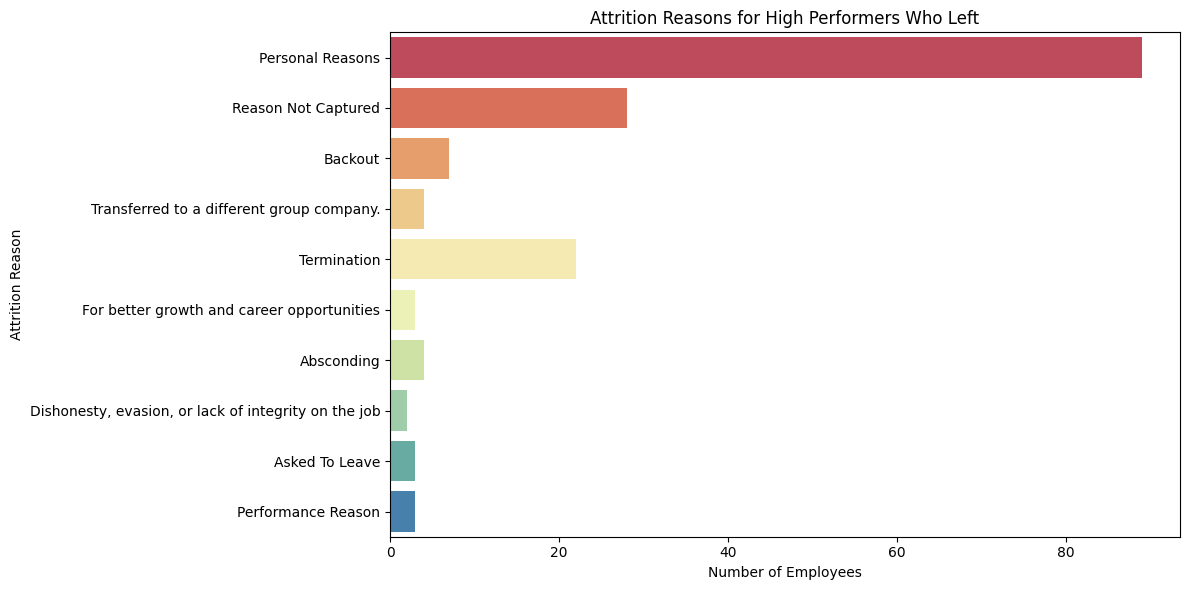

In [ ]:
# Analyze attrition reason for high performers who left
plt.figure(figsize=(12, 6))
sns.countplot(y='Attrition Reason', data=high_performers_left, palette='Spectral')
plt.title('Attrition Reasons for High Performers Who Left')
plt.xlabel('Number of Employees')
plt.ylabel('Attrition Reason')
plt.tight_layout()
plt.show()


### Creating Bins

In [ ]:
# Create tenure bins (e.g., 0-2, 3-5, 6+ years)
df['Tenure Group'] = pd.cut(df['Tenure'], bins=[0, 2, 5, 10, float('inf')], labels=['0-2 years', '3-5 years', '6-10 years', '10+ years'])


In [ ]:
# Create engagement score bins (Low, Medium, High)
df['Engagement Level'] = pd.cut(df['Engagement Score'], bins=[0, 50, 75, 100], labels=['Low', 'Medium', 'High'])


In [ ]:
# Encode Performance and Potential columns as numeric (if not already done)
performance_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
potential_mapping = {'Low': 1, 'Medium': 2, 'High': 3}

df['Performance_Numeric'] = df['Performance'].map(performance_mapping)
df['Potential_Numeric'] = df['Potential'].map(potential_mapping)

# Create interaction term between performance and potential
df['Performance_Potential_Interaction'] = df['Performance_Numeric'] * df['Potential_Numeric']


In [ ]:
# Calculate time since last promotion (assuming Date Of Joining and Last Promotion Date are in datetime format)
df['Time Since Last Promotion (Months)'] = (df['Date Of Exit'] - df['Last Promotion Date']).dt.days / 30

# Calculate time until retirement (assuming Expected Retirement Date is in datetime format)
df['Time Until Retirement (Years)'] = (df['Expected Retirement Date'] - df['Date Of Exit']).dt.days / 365


## Modelling of Data and preprocessing

In [ ]:
# Relevant features based on your feature engineering
features = ['Tenure Group', 'Engagement Level', 'Performance_Potential_Interaction',
            'Time Since Last Promotion (Months)', 'Time Until Retirement (Years)', 'Gender', 'Marital Status']

# Target variable: Predicting whether the employee is 'Inactive' (i.e., attrition)
target = 'Employment Status'

# Convert categorical features to numeric using one-hot encoding
df_encoded = pd.get_dummies(df[features])

# Map the target variable (Employment Status) to binary (Active = 0, Inactive = 1)
df_encoded[target] = df[target].map({'Active': 0, 'Inactive': 1})

# Drop missing values (optional: you can use imputation instead if needed)
df_encoded.dropna(inplace=True)


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
clf = DecisionTreeClassifier(random_state=42)

# Fit the model on the training data
clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
# Set class weights to balance the importance of classes
clf_weighted = DecisionTreeClassifier(random_state=42, class_weight={0: 1, 1: 5})

# Train the model
clf_weighted.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred_weighted = clf_weighted.predict(X_test)

# Print new accuracy, confusion matrix, and classification report
print(f"New Accuracy: {accuracy_score(y_test, y_pred_weighted):.2f}")
print("New Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted))
print("New Classification Report:")
print(classification_report(y_test, y_pred_weighted))


New Accuracy: 0.83
New Confusion Matrix:
[[0 1]
 [0 5]]
New Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.83      1.00      0.91         5

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



In [ ]:
from prettytable import PrettyTable

# Assuming df is your DataFrame
# Select only relevant features
selected_features = ['Tenure Group', 'Gender', 'Marital Status']
X_selected = df[selected_features]
y_selected = df['Employment Status']  # Assuming 'Employment Status' is the target variable

# One-hot encode categorical features
X_selected_encoded = pd.get_dummies(X_selected, drop_first=True)

# Split the data into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected_encoded, y_selected, test_size=0.2, random_state=42
)

# Initialize and train the Decision Tree Classifier
decision_tree_selected = DecisionTreeClassifier(random_state=42)
decision_tree_selected.fit(X_train_selected, y_train_selected)

# Make predictions on the test set
y_pred_selected = decision_tree_selected.predict(X_test_selected)

# Evaluate the model
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
confusion_matrix_selected = confusion_matrix(y_test_selected, y_pred_selected)
classification_report_selected = classification_report(y_test_selected, y_pred_selected, output_dict=True)

# Create confusion matrix table
conf_table = PrettyTable()
conf_table.field_names = ["Predicted", "Active", "Inactive"]
conf_table.add_row(["Active", confusion_matrix_selected[0][0], confusion_matrix_selected[0][1]])
conf_table.add_row(["Inactive", confusion_matrix_selected[1][0], confusion_matrix_selected[1][1]])

# Print confusion matrix
print("Confusion Matrix:")
print(conf_table)

# Create classification report table
report_table = PrettyTable()
report_table.field_names = ["Class", "Precision", "Recall", "F1-Score", "Support"]

for label, metrics in classification_report_selected.items():
    if label not in ["accuracy", "macro avg", "weighted avg"]:
        report_table.add_row([label,
                               f"{metrics['precision']:.2f}",
                               f"{metrics['recall']:.2f}",
                               f"{metrics['f1-score']:.2f}",
                               int(metrics['support'])])

# Print classification report
print("\nClassification Report:")
print(report_table)

# Print overall accuracy
print(f"\nAccuracy: {accuracy_selected:.2f}")


Confusion Matrix:
+-----------+--------+----------+
| Predicted | Active | Inactive |
+-----------+--------+----------+
|   Active  |  161   |    44    |
|  Inactive |   14   |    64    |
+-----------+--------+----------+

Classification Report:
+----------+-----------+--------+----------+---------+
|  Class   | Precision | Recall | F1-Score | Support |
+----------+-----------+--------+----------+---------+
|  Active  |    0.92   |  0.79  |   0.85   |   205   |
| Inactive |    0.59   |  0.82  |   0.69   |    78   |
+----------+-----------+--------+----------+---------+

Accuracy: 0.80


### Interpretation:
- **Confusion Matrix**:
  - The model correctly predicted **161** instances of Active employees and **64** instances of Inactive employees.
  - There were **44** false positives (predicted Active but actually Inactive) and **14** false negatives (predicted Inactive but actually Active).

- **Classification Report**:
  - **Precision**: The precision for Active is high (0.92), indicating that most of the predicted Active cases are indeed Active. For Inactive, it's lower (0.59), suggesting more false positives.
  - **Recall**: The recall for Active is lower (0.79), meaning that the model misses some Active employees. The recall for Inactive is better (0.82), indicating that most Inactive cases are correctly identified.
  - **F1-Score**: This metric balances precision and recall, with Active performing better (0.85) than Inactive (0.69).

In [ ]:
from prettytable import PrettyTable

# Assuming df is your DataFrame
# Select only relevant features
selected_features = ['Performance', 'Potential', 'Tenure']
X_selected = df[selected_features]
y_selected = df['Employment Status']  # Assuming 'Employment Status' is the target variable

# One-hot encode categorical features
X_selected_encoded = pd.get_dummies(X_selected, drop_first=True)

# Split the data into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected_encoded, y_selected, test_size=0.2, random_state=42
)

# Initialize and train the Decision Tree Classifier
decision_tree_selected = DecisionTreeClassifier(random_state=42)
decision_tree_selected.fit(X_train_selected, y_train_selected)

# Make predictions on the test set
y_pred_selected = decision_tree_selected.predict(X_test_selected)

# Evaluate the model
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
confusion_matrix_selected = confusion_matrix(y_test_selected, y_pred_selected)
classification_report_selected = classification_report(y_test_selected, y_pred_selected, output_dict=True)

# Create confusion matrix table
conf_table = PrettyTable()
conf_table.field_names = ["Predicted", "Active", "Inactive"]
conf_table.add_row(["Active", confusion_matrix_selected[0][0], confusion_matrix_selected[0][1]])
conf_table.add_row(["Inactive", confusion_matrix_selected[1][0], confusion_matrix_selected[1][1]])

# Print confusion matrix
print("Confusion Matrix:")
print(conf_table)

# Create classification report table
report_table = PrettyTable()
report_table.field_names = ["Class", "Precision", "Recall", "F1-Score", "Support"]

for label, metrics in classification_report_selected.items():
    if label not in ["accuracy", "macro avg", "weighted avg"]:
        report_table.add_row([label,
                               f"{metrics['precision']:.2f}",
                               f"{metrics['recall']:.2f}",
                               f"{metrics['f1-score']:.2f}",
                               int(metrics['support'])])

# Print classification report
print("\nClassification Report:")
print(report_table)

# Print overall accuracy
print(f"\nAccuracy: {accuracy_selected:.2f}")


Confusion Matrix:
+-----------+--------+----------+
| Predicted | Active | Inactive |
+-----------+--------+----------+
|   Active  |  204   |    1     |
|  Inactive |   77   |    1     |
+-----------+--------+----------+

Classification Report:
+----------+-----------+--------+----------+---------+
|  Class   | Precision | Recall | F1-Score | Support |
+----------+-----------+--------+----------+---------+
|  Active  |    0.73   |  1.00  |   0.84   |   205   |
| Inactive |    0.50   |  0.01  |   0.03   |    78   |
+----------+-----------+--------+----------+---------+

Accuracy: 0.72


### Interpretation:

**Confusion Matrix:**

- The model correctly predicted **204 instances** of **Active** employees and **1 instance** of **Inactive** employees.
- There were **1 false positive** (predicted Active but actually Inactive) and **77 false negatives** (predicted Inactive but actually Active).

**Classification Report:**

- **Precision**: The precision for **Active** is **0.73**, indicating that about 73% of the predicted Active cases are indeed Active. The precision for **Inactive** is **0.50**, suggesting that there are quite a few false positives in this category.

- **Recall**: The recall for **Active** is **1.00**, meaning the model correctly identified all actual Active employees. However, the recall for **Inactive** is **0.01**, indicating that the model is missing almost all actual Inactive cases, only identifying 1 out of 78 correctly.

- **F1-Score**: The F1-Score for **Active** is **0.84**, reflecting a good balance between precision and recall for Active employees. Conversely, the F1-Score for **Inactive** is very low at **0.03**, showing that the model is not performing well in identifying Inactive employees.

In [ ]:
# Select only relevant features for the model
selected_features = ['Tenure Group', 'Gender', 'Marital Status']
X = df[selected_features]
y = df['Employment Status']  # Assuming 'Employment Status' is the target variable

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Initialize and train the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_encoded, y)

# Function to predict employee attrition
def predict_attrition(tenure_group, gender, marital_status):
    # Create a DataFrame for the input
    input_data = pd.DataFrame({
        'Tenure Group': [tenure_group],
        'Gender': [gender],
        'Marital Status': [marital_status]
    })

    # One-hot encode the input data
    input_encoded = pd.get_dummies(input_data, drop_first=True)

    # Align the input DataFrame with the model training DataFrame
    input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)

    # Make the prediction
    prediction = decision_tree.predict(input_encoded)

    return prediction[0]  # Return the predicted class

# User input
tenure_group = input("Enter Employee's Tenure Group (e.g., '0-2 years', '3-5 years', '6-10 years', '10+ years'): ")
gender = input("Enter Employee's Gender (e.g., 'Male', 'Female'): ")
marital_status = input("Enter Employee's Marital Status (e.g., 'Single', 'Married', 'Divorced', 'Separated'): ")

# Predict and display result
result = predict_attrition(tenure_group, gender, marital_status)
status = "Active" if result == "Active" else "Inactive"
print(f"The predicted status for the employee is: {status}")

Enter Employee's Tenure Group (e.g., '0-2 years', '3-5 years', '6-10 years', '10+ years'): 0-2 years
Enter Employee's Gender (e.g., 'Male', 'Female'): Male
Enter Employee's Marital Status (e.g., 'Single', 'Married', 'Divorced', 'Separated'): Single
The predicted status for the employee is: Inactive


### SVM Modelling

In [ ]:
# Select features and target variable
selected_features = ['Tenure Group', 'Gender', 'Marital Status']  # Change as needed
X_selected = df[selected_features]
y_selected = df['Employment Status']  # Assuming 'Employment Status' is the target variable

# One-hot encode categorical features
X_selected_encoded = pd.get_dummies(X_selected, drop_first=True)

# Split the data into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected_encoded, y_selected, test_size=0.2, random_state=42
)

# Initialize and train the SVM Classifier
svm_classifier = SVC(kernel='linear', random_state=42)  # You can try different kernels like 'rbf', 'poly', etc.
svm_classifier.fit(X_train_selected, y_train_selected)

# Make predictions on the test set
y_pred_selected = svm_classifier.predict(X_test_selected)

# Evaluate the model
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
confusion_matrix_selected = confusion_matrix(y_test_selected, y_pred_selected)
classification_report_selected = classification_report(y_test_selected, y_pred_selected, output_dict=True)


In [ ]:
conf_table = PrettyTable()
conf_table.field_names = ["Predicted", "Active", "Inactive"]
conf_table.add_row(["Active", confusion_matrix_selected[0][0], confusion_matrix_selected[0][1]])
conf_table.add_row(["Inactive", confusion_matrix_selected[1][0], confusion_matrix_selected[1][1]])

# Print confusion matrix
print("Confusion Matrix:")
print(conf_table)

# Classification Report
report_table = PrettyTable()
report_table.field_names = ["Class", "Precision", "Recall", "F1-Score", "Support"]

# Fill the table with classification report data
for label, metrics in classification_report_selected.items():
    if label not in ["accuracy", "macro avg", "weighted avg"]:
        report_table.add_row([label,
                              f"{metrics['precision']:.2f}",
                              f"{metrics['recall']:.2f}",
                              f"{metrics['f1-score']:.2f}",
                              int(metrics['support'])])

# Print classification report
print("\nClassification Report:")
print(report_table)

# Print overall accuracy
print(f"\nAccuracy: {accuracy_selected:.2f}")


Confusion Matrix:
+-----------+--------+----------+
| Predicted | Active | Inactive |
+-----------+--------+----------+
|   Active  |  160   |    45    |
|  Inactive |   14   |    64    |
+-----------+--------+----------+

Classification Report:
+----------+-----------+--------+----------+---------+
|  Class   | Precision | Recall | F1-Score | Support |
+----------+-----------+--------+----------+---------+
|  Active  |    0.92   |  0.78  |   0.84   |   205   |
| Inactive |    0.59   |  0.82  |   0.68   |    78   |
+----------+-----------+--------+----------+---------+

Accuracy: 0.79


### Interpretation:

**Confusion Matrix:**

- The model correctly predicted 160 instances of Active employees and 64 instances of Inactive employees.
- There were 45 false positives (predicted Active but actually Inactive) and 14 false negatives (predicted Inactive but actually Active).

**Classification Report:**

- **Precision:**
  - The precision for **Active** is 0.92, meaning 92% of the employees predicted to be Active are indeed Active. This high precision indicates fewer false positives.
  - The precision for **Inactive** is 0.59, meaning only 59% of the employees predicted to be Inactive are truly Inactive, indicating a moderate level of false positives in this category.

- **Recall:**
  - The recall for **Active** is 0.78, meaning the model correctly identified 78% of all Active employees. This suggests that 22% of Active employees were incorrectly classified as Inactive.
  - The recall for **Inactive** is 0.82, meaning the model identified 82% of the actual Inactive employees correctly. This indicates a relatively strong performance for this category.

- **F1-Score:**
  - The F1-Score for **Active** is 0.84, which represents a good balance between precision and recall for predicting Active employees.
  - The F1-Score for **Inactive** is 0.68, indicating a somewhat moderate performance in identifying Inactive employees. This suggests that while the recall is high, the precision could be improved.


### Ensembling

For ensembling based on the data and analysis so far, we can consider the following models:

1. Decision Tree: Simple model that captures non-linear patterns well, but may overfit.
2. Support Vector Machine (SVM): Good at separating classes with a margin, particularly useful for binary classification.
3. Random Forest: An ensemble of decision trees that reduces overfitting by averaging predictions.
4. Gradient Boosting (e.g., XGBoost, LightGBM): These models build trees sequentially, each focusing on correcting the mistakes of the previous one. They work well on tabular data with categorical features.
5. Logistic Regression: Useful for providing a baseline, capturing linear relationships.

A combination of **Random Forest** and **Gradient Boosting** would likely be effective here, as they both handle categorical features well and are known to be strong ensemble methods. Adding SVM and Decision Tree into a voting ensemble or stacking approach can further enhance performance.

In [ ]:
# Features selection
selected_features = ['Tenure Group', 'Gender', 'Marital Status']
X_selected = df[selected_features]
y_selected = df['Employment Status']  # Assuming 'Employment Status' is the target variable

# One-hot encode categorical features
X_selected_encoded = pd.get_dummies(X_selected, drop_first=True)

# Split the data into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected_encoded, y_selected, test_size=0.2, random_state=42
)

# Initialize the models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
gradient_boosting = GradientBoostingClassifier(random_state=42)
svc = SVC(probability=True, random_state=42)
log_reg = LogisticRegression()

# Create the ensemble model using VotingClassifier
voting_clf = VotingClassifier(estimators=[
    ('decision_tree', decision_tree),
    ('random_forest', random_forest),
    ('gradient_boosting', gradient_boosting),
    ('svc', svc),
    ('log_reg', log_reg)
], voting='soft')  # 'soft' uses predicted probabilities for voting

# Train the ensemble model
voting_clf.fit(X_train_selected, y_train_selected)

# Make predictions
y_pred_ensemble = voting_clf.predict(X_test_selected)

# Evaluate the model
accuracy_ensemble = accuracy_score(y_test_selected, y_pred_ensemble)
confusion_matrix_ensemble = confusion_matrix(y_test_selected, y_pred_ensemble)
classification_report_ensemble = classification_report(y_test_selected, y_pred_ensemble, output_dict=True)

# Confusion Matrix Table
conf_table = PrettyTable()
conf_table.field_names = ["Predicted", "Active", "Inactive"]
conf_table.add_row(["Active", confusion_matrix_ensemble[0][0], confusion_matrix_ensemble[0][1]])
conf_table.add_row(["Inactive", confusion_matrix_ensemble[1][0], confusion_matrix_ensemble[1][1]])

# Print Confusion Matrix
print("Confusion Matrix:")
print(conf_table)

# Classification Report Table
report_table = PrettyTable()
report_table.field_names = ["Class", "Precision", "Recall", "F1-Score", "Support"]

# Fill the table with classification report data
for label, metrics in classification_report_ensemble.items():
    if label not in ["accuracy", "macro avg", "weighted avg"]:
        report_table.add_row([label,
                              f"{metrics['precision']:.2f}",
                              f"{metrics['recall']:.2f}",
                              f"{metrics['f1-score']:.2f}",
                              int(metrics['support'])])

# Print Classification Report
print("\nClassification Report:")
print(report_table)

# Print overall accuracy
print(f"\nEnsemble Model Accuracy: {accuracy_ensemble:.2f}")


NameError: name 'VotingClassifier' is not defined